## Análisis de los niveles de O3 en Montevideo
### Para esto, se utilizaron los datasets publicos dispuestos por la Intendencia Municipal de Montevideo.
![Imagen_de_la_imm](https://www.gub.uy/catalogo-participacion-ciudadana/sites/catalogo-participacion-ciudadana/files/styles/documento/public/2024-05/Logo%20Intendencia%20de%20Montevideo_3.png?itok=dmOKXdGC)

### Información sobre el dataset:

— Rango de fechas: 2024-01-01 hasta 2026-09-19 (desde el primer hasta el último registro)

— Estaciones de control que miden el O3: "Maroñas" y "Colón", las demás miden NO2 o PM 2.5

— Cantidad de regristros: 2.188.716

— Cantidad de columnas: 6

— Cantidad de regristros nulos: 373.205

## Importación de los datos

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
BASE_URL = "https://ckan.montevideo.gub.uy"
DATASET_ID_O3 = "calidad-del-aire-ozono-o3"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

r_o3 = requests.get(f"{BASE_URL}/api/3/action/package_show", params={"id": DATASET_ID_O3}, headers=headers)
resources_o3 = r_o3.json()["result"]["resources"]

for res in resources_o3:
    print(res["name"], "-", res["format"], "-", res["url"])

dfs_o3 = []
for res in resources_o3:
    if res["format"].upper() == "CSV":
        try:
            df = pd.read_csv(res["url"], storage_options=headers)
            df["archivo_origen"] = res["name"]
            dfs_o3.append(df)
        except Exception as e:
            print(f"Error con {res['name']}: {e}")

o3_completo = pd.concat(dfs_o3, ignore_index=True)

O3  01-2024 - 04-2024 - CSV - https://ckan-data.montevideo.gub.uy/dataset/70a1a63d-4157-43c0-9ae6-00fc14dae29a/resource/a97d7ffb-be66-4438-8de8-fa4c7cacf66c/download/o3_01_2024_04_2024.csv
O3  05-2024 - 08-2024 - CSV - https://ckan-data.montevideo.gub.uy/dataset/70a1a63d-4157-43c0-9ae6-00fc14dae29a/resource/e5d34ea0-6f21-410c-9085-bf913fbdede8/download/o3_05_2024_08_2024.csv
O3  09-2024 - 12-2024 - CSV - https://ckan-data.montevideo.gub.uy/dataset/70a1a63d-4157-43c0-9ae6-00fc14dae29a/resource/7f650358-e61a-434c-8953-e2c08ca0f738/download/o3_09_2024_12_2024.csv
O3  01-2025 - 04-2025 - CSV - https://ckan-data.montevideo.gub.uy/dataset/70a1a63d-4157-43c0-9ae6-00fc14dae29a/resource/a33889b6-a121-415d-aa9c-907c28ee7bfd/download/o3_01_2025_04_2025.csv
O3  05-2025 - 08-2025 - CSV - https://ckan-data.montevideo.gub.uy/dataset/70a1a63d-4157-43c0-9ae6-00fc14dae29a/resource/31628cd8-7222-4c69-b017-6584f0eaef75/download/o3_05_2025_08_2025.csv
O3  09-2025 - 12-2025 - CSV - https://ckan-data.montevi

## Visualización primaria de los datos

In [ ]:
o3_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191596 entries, 0 to 2191595
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   fecha           object 
 1   o3              float64
 2   estacion        object 
 3   longitud        float64
 4   latitud         float64
 5   archivo_origen  object 
dtypes: float64(3), object(3)
memory usage: 100.3+ MB


In [ ]:
o3_completo.shape

(2191596, 6)

In [ ]:
o3_completo.head()

,fecha,o3,estacion,longitud,latitud,archivo_origen
0,2024-01-01 00:00:00,6.0,Colón,-56.224168,-34.798337,O3 01-2024 - 04-2024
1,2024-01-01 00:00:00,NaN,Curva de Maroñas,-56.133249,-34.858960,O3 01-2024 - 04-2024
2,2024-01-01 00:01:00,8.0,Colón,-56.224168,-34.798337,O3 01-2024 - 04-2024
3,2024-01-01 00:01:00,NaN,Curva de Maroñas,-56.133249,-34.858960,O3 01-2024 - 04-2024
4,2024-01-01 00:02:00,8.0,Colón,-56.224168,-34.798337,O3 01-2024 - 04-2024


In [ ]:
o3_completo.tail()

,fecha,o3,estacion,longitud,latitud,archivo_origen
2191591,2026-09-21 23:55:00,77.0,Colón,-56.224168,-34.798337,O3 09-2026 - 12-2026
2191592,2026-09-21 23:56:00,79.0,Colón,-56.224168,-34.798337,O3 09-2026 - 12-2026
2191593,2026-09-21 23:57:00,75.0,Colón,-56.224168,-34.798337,O3 09-2026 - 12-2026
2191594,2026-09-21 23:58:00,75.0,Colón,-56.224168,-34.798337,O3 09-2026 - 12-2026
2191595,2026-09-21 23:59:00,75.0,Colón,-56.224168,-34.798337,O3 09-2026 - 12-2026


In [ ]:
o3_completo.isna().sum()

,0
fecha,0
o3,373263
estacion,0
longitud,0
latitud,0
archivo_origen,0


In [ ]:
print(f"---------------------------------")
print(o3_completo["estacion"].value_counts())
print(f"La cantidad de entradas son: //// {o3_completo['estacion'].value_counts().sum()} ////")
print(f"---------------------------------")
print(o3_completo.groupby("estacion")["o3"].apply(lambda x: x.isna().mean() * 100).round(1))
print(f"---------------------------------")
print(o3_completo.groupby("archivo_origen")["o3"].apply(lambda x: x.isna().mean() * 100).round(1))
print(f"---------------------------------")

---------------------------------
estacion
Curva de Maroñas    1273297
Colón                918299
Name: count, dtype: int64
La cantidad de entradas son: //// 2191596 ////
---------------------------------
estacion
Colón               18.9
Curva de Maroñas    15.7
Name: o3, dtype: float64
---------------------------------
archivo_origen
O3  01-2024 - 04-2024    12.4
O3  01-2025 - 04-2025     2.8
O3  01-2026 - 04-2026     1.6
O3  05-2024 - 08-2024    14.2
O3  05-2025 - 08-2025    26.1
O3  05-2026 - 08-2026    21.3
O3  09-2024 - 12-2024     3.6
O3  09-2025 - 12-2025    39.5
O3  09-2026 - 12-2026    29.3
Name: o3, dtype: float64
---------------------------------


## EDA

In [ ]:
# Antes que nada, se registra las filas antes de limpiar
fa = len(o3_completo) # fa = filas_antes

# Se limpian los NaN de la columna O3
df_purgado = o3_completo.dropna(subset=["o3"]).copy()

# Se registra las filas después de limpiar
fd = len(df_purgado) # fd = filas_después

filas_descartadas = fa - fd
porcentaje_conservado = (fd / fa) * 100

print(f"Filas originales:     {fa:,}")
print(f"Filas conservadas:    {fd:,}")
print(f"Filas descartadas:    {filas_descartadas:,}")
print(f"Porcentaje restante:  {porcentaje_conservado:.2f}%")

Filas originales:     2,191,596
Filas conservadas:    1,818,333
Filas descartadas:    373,263
Porcentaje restante:  82.97%


In [ ]:
df_purgado.dtypes
# Hay que convertir la columna de "fecha", la cual es "object" en datetime

,0
fecha,object
o3,float64
estacion,object
longitud,float64
latitud,float64
archivo_origen,object


In [ ]:
# Convertir la columna 'fecha' de texto (object) a datetime real de pandas
df_purgado['fecha'] = pd.to_datetime(df_purgado['fecha'])

# Extraer la hora de la comuna fecha, crear su propia columna
df_purgado['hora_de_la_muestra'] = df_purgado['fecha'].dt.hour

# Crear columna de día de semana
df_purgado['dia_semana'] = df_purgado['fecha'].dt.day_name()

# Crear columna categórica simplificada: día de semana vs. fin de semana
df_purgado['tipo_dia'] = df_purgado['fecha'].dt.dayofweek.apply(lambda x: "Fin de semana" if x >= 5 else "Día de semana")

df_purgado = df_purgado.reset_index(drop=True)
print(f"---------------------------------")
print(df_purgado["estacion"].value_counts())
print(f"---------------------------------")
print(f"La cantidad de entradas son: //// {df_purgado['estacion'].value_counts().sum()} ////")
print(f"Estación 'Curva de Maroñas' - % de datos restante: {round((199515 / 1273297) * 100, 1)}%")
print(f"Estación 'Colón' - % de datos restante: {round((172250 / 913979) * 100, 1)}%")

---------------------------------
estacion
Curva de Maroñas    1073782
Colón                744551
Name: count, dtype: int64
---------------------------------
La cantidad de entradas son: //// 1818333 ////
Estación 'Curva de Maroñas' - % de datos restante: 15.7%
Estación 'Colón' - % de datos restante: 18.8%


In [ ]:
df_purgado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818333 entries, 0 to 1818332
Data columns (total 9 columns):
 #   Column              Dtype         
---  ------              -----         
 0   fecha               datetime64[ns]
 1   o3                  float64       
 2   estacion            object        
 3   longitud            float64       
 4   latitud             float64       
 5   archivo_origen      object        
 6   hora_de_la_muestra  int32         
 7   dia_semana          object        
 8   tipo_dia            object        
dtypes: datetime64[ns](1), float64(3), int32(1), object(4)
memory usage: 117.9+ MB


## Exportación a CSV intermedio
### A continuación se exportará el dataset como resultado del Exploratory Data Analysis

In [ ]:
df_purgado.to_csv("Dataset_O3_listo.csv", index=False)


![metodología](https://cdn.aicad.es/asset/img/4/metodologia.jpg)
## Decisiones tomadas sobre la limpieza de datos

### 1. Cambio de contaminante: de NO2 a O3

Inicialmente se trabajó con el dataset de Dióxido de Nitrógeno (NO2), pero se detectó que ~70%
de sus valores eran nulos, distribuidos en bloques trimestrales completos (varios trimestres al
100% de nulos) — un patrón compatible con un problema de publicación del dataset, no con fallas
normales de sensor. Se envió una consulta a datosabiertos@imm.gub.uy para confirmar la causa
(respuesta pendiente).

Se optó por continuar el análisis con Ozono (O3), que presenta ~17% de nulos distribuidos de
forma gradual por trimestre (entre 1.6% y 39.5%, sin bloques en 0% o 100%), consistente con
interrupciones normales de sensor y apto para el análisis.

### 2. Tratamiento de valores nulos en la columna 'o3'

El dataset de O3 contenía 373.205 filas con valores nulos en la columna 'o3' (17.05% del total
de 2.188.716 filas). Se optó por eliminar estas filas (dropna) en lugar de imputarlas
(por ejemplo, con media o mediana), por dos razones:

1. El volumen de nulos era demasiado alto (17%) como para imputar sin distorsionar la varianza
   real de los datos — rellenar esa proporción con un único valor central achataría
   artificialmente la distribución, afectando directamente los análisis estadísticos posteriores
   (Día 4: tests de inferencia, que dependen de la varianza real).
2. La columna 'o3' es la variable de interés central del análisis — no tiene sentido inventar
   el propio dato que se busca estudiar.

Resultado: 1.815.511 filas conservadas (82.95% del total).

### 3. Verificación de sesgo por estación tras la limpieza

Se verificó que la eliminación de nulos no afectara desproporcionadamente a una de las dos
estaciones disponibles (Colón y Curva de Maroñas):

- Curva de Maroñas: perdió 15.67% de sus registros originales.
- Colón: perdió 18.85% de sus registros originales.

La diferencia entre ambas (≈3 puntos porcentuales) se considera menor y no introduce un sesgo
relevante para la comparación entre estaciones planeada en el análisis inferencial.

### 4. Reseteo del índice

Se reinició el índice del DataFrame tras la eliminación de filas, por motivos de
legibilidad: pandas no renumera automáticamente el índice al eliminar filas, dejando huecos en
la numeración. Esto no afecta los cálculos estadísticos ni la performance, es únicamente una
decisión de prolijidad.

### 5. Columnas derivadas de fecha

A partir de la columna 'fecha' (convertida de texto a datetime) se derivaron tres columnas
nuevas: 'hora_de_la_muestra' (0-23, para analizar variación horaria del O3), 'dia_semana'
(nombre del día) y 'tipo_dia' (Día de semana / Fin de semana, agrupando sábado y domingo).

### 6. Exportación

El dataset resultante, limpio y con las columnas derivadas, se exportó como archivo CSV
intermedio para continuar el análisis exploratorio sin necesidad de repetir la
descarga y limpieza en cada sesión de trabajo.

## Estadística descriptiva.

### Identificación y manejo de outliers

Al calcular las estadísticas descriptivas por estación y tipo de día se detectaron dos tipos de
valores atípicos en la columna 'o3': **285 valores negativos** (mínimo de -12.0 µg/m³) y **1.002
valores por encima de 150 µg/m³** (máximo de 268.0 µg/m³).

**Valores negativos:** una concentración negativa de un gas no tiene sentido físico, por lo que
se trata de un error de sensor o de carga de datos, no de una medición real. Para confirmar la
causa e informar el criterio de tratamiento, se consultó al Dr. José Cataldo (Facultad de
Ingeniería, UdelaR), quien indicó que los valores
negativos en sensores de ozono suelen corresponder a indicaciones de cero mal codificadas.
Siguiendo esta recomendación, se convirtieron todos los valores negativos a 0
(`df_purgado.loc[df_purgado['o3'] < 0, 'o3'] = 0`), en lugar de eliminar esas filas, ya que
representan mediciones reales (concentración nula o cercana a cero) y no datos inválidos que
deban descartarse.

**Valores altos (picos):** ante la misma consulta, el Dr. Cataldo señaló que valores del orden
de 260 µg/m³, si bien elevados, son "del orden de magnitud de valores pico usuales como 120 y
140" — es decir, mediciones reales y esperables del fenómeno, no errores de sensor ni eventos
ambientales extraordinarios. Por este motivo, **se decidió conservar estos valores en el
análisis y en las visualizaciones**, en lugar de excluirlos como outliers, dado que ocultarlos
distorsionaría la representación real del comportamiento del O3 en Montevideo. El análisis de la
distribución horaria de estos picos (ver más abajo) confirmó que se concentran mayoritariamente
entre las 12 y las 18hs, consistente con el ciclo fotoquímico conocido del ozono troposférico.

**Consideraciones**: Se debe tener en cuenta que se envió mensajes también a la Gerencia de Gestión Ambiental de la Intendencia Municipal de Montevideo. Se les preguntó sobre la integridad de los datos. Sin embargo, no se percibió respuesta.

In [ ]:
df_purgado.describe()

,fecha,o3,longitud,latitud,hora_de_la_muestra
count,1818333,1.818333e+06,1.818333e+06,1.818333e+06,1.818333e+06
mean,2025-05-30 23:14:31.078895360,4.110333e+01,-5.617048e+01,-3.483414e+01,1.133045e+01
min,2024-01-01 00:00:00,-1.200000e+01,-5.622417e+01,-3.485896e+01,0.000000e+00
25%,2024-08-05 01:52:00,2.400000e+01,-5.622417e+01,-3.485896e+01,5.000000e+00
50%,2025-07-24 16:05:00,3.700000e+01,-5.613325e+01,-3.485896e+01,1.100000e+01
75%,2026-02-26 01:14:00,5.700000e+01,-5.613325e+01,-3.479834e+01,1.700000e+01
max,2026-09-21 23:59:00,2.680000e+02,-5.613325e+01,-3.479834e+01,2.300000e+01
std,NaN,2.380602e+01,4.470814e-02,2.981051e-02,6.787617e+00


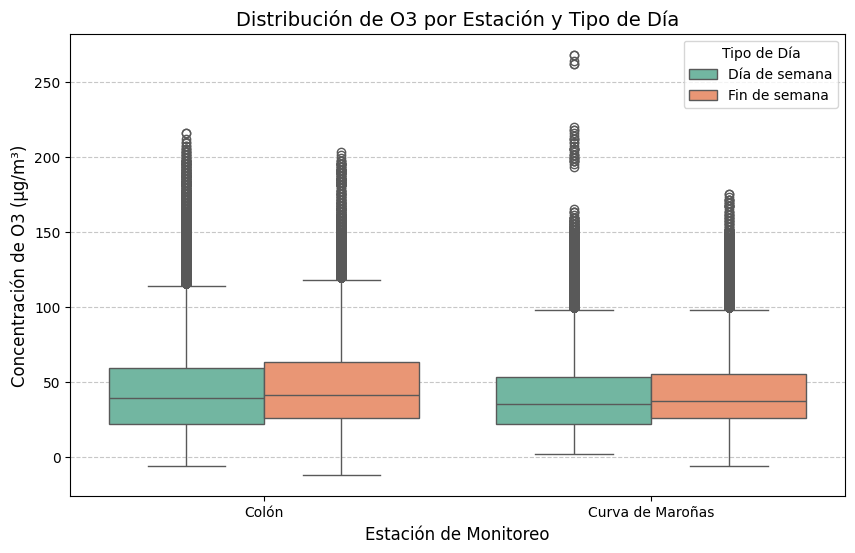

In [ ]:
# La idea es usar este boxplot para revisar los datos extraños, sobre todo aquellos negativos y las mediciones extremadamente altas
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_purgado,
    x='estacion',
    y='o3',
    hue='tipo_dia',
    palette='Set2',
    showfliers=True
)
plt.title("Distribución de O3 por Estación y Tipo de Día", fontsize=14)
plt.xlabel("Estación de Monitoreo", fontsize=12)
plt.ylabel("Concentración de O3 (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Tipo de Día")
plt.show()

In [ ]:
# Métricas agregadas por Estación y Tipo de Día
resumen_estadistico = df_purgado.groupby(["estacion", "tipo_dia"])["o3"].agg(
    Count='count',
    Media='mean',
    Mediana='median',
    Desvio_Std='std',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Minimo='min',
    Maximo='max'
).reset_index()

# Formatear números a 2 decimales para lectura clara
resumen_estadistico.round(2)

,estacion,tipo_dia,Count,Media,Mediana,Desvio_Std,IQR,Minimo,Maximo
0,Colón,Día de semana,534689,41.86,39.0,25.12,37.0,-6.0,216.0
1,Colón,Fin de semana,209862,45.83,41.0,25.41,37.0,-12.0,203.0
2,Curva de Maroñas,Día de semana,768304,39.00,35.0,22.36,31.0,2.0,268.0
3,Curva de Maroñas,Fin de semana,305478,41.81,37.0,23.24,29.0,-6.0,175.0


In [ ]:
# Los datos arrojaron un problema: ¿qué son esos outliers en los datos?
# Tenemos que averiguar qué pasó, qué significan esos mínimos negativos y los máximos llamativos
# Debido a que es físicamente imposible una cantidad negativa de o3 µg/m³, debe ser cantidades que el sensor no puede detectar

o3_mayor_150 = df_purgado[df_purgado["o3"] > 150]
o3_mayor_150.sort_values(by = 'fecha')
o3_menor_0 = df_purgado[df_purgado["o3"] <= 0]
o3_menor_0.sort_values(by = 'fecha')

,fecha,o3,estacion,longitud,latitud,archivo_origen,hora_de_la_muestra,dia_semana,tipo_dia
610875,2024-12-07 21:51:00,0.0,Curva de Maroñas,-56.133249,-34.858960,O3 09-2024 - 12-2024,21,Saturday,Fin de semana
610881,2024-12-07 21:57:00,0.0,Curva de Maroñas,-56.133249,-34.858960,O3 09-2024 - 12-2024,21,Saturday,Fin de semana
610882,2024-12-07 21:58:00,0.0,Curva de Maroñas,-56.133249,-34.858960,O3 09-2024 - 12-2024,21,Saturday,Fin de semana
610883,2024-12-07 21:59:00,0.0,Curva de Maroñas,-56.133249,-34.858960,O3 09-2024 - 12-2024,21,Saturday,Fin de semana
610884,2024-12-07 22:00:00,-1.0,Curva de Maroñas,-56.133249,-34.858960,O3 09-2024 - 12-2024,22,Saturday,Fin de semana
...,...,...,...,...,...,...,...,...,...
1523046,2026-04-23 11:27:00,0.0,Colón,-56.224168,-34.798337,O3 01-2026 - 04-2026,11,Thursday,Día de semana
1523047,2026-04-23 11:28:00,0.0,Colón,-56.224168,-34.798337,O3 01-2026 - 04-2026,11,Thursday,Día de semana
1528038,2026-04-25 11:58:00,-1.0,Colón,-56.224168,-34.798337,O3 01-2026 - 04-2026,11,Saturday,Fin de semana
1530639,2026-04-26 09:40:00,0.0,Colón,-56.224168,-34.798337,O3 01-2026 - 04-2026,9,Sunday,Fin de semana


In [ ]:
print(f"I) La cantidad de filas de o3 > 150 son: {len(o3_mayor_150)}µg/m³")
print(f"II) La cantidad de filas de o3 <= 0 son: {len(o3_menor_0)}µg/m³")

I) La cantidad de filas de o3 > 150 son: 1002µg/m³
II) La cantidad de filas de o3 <= 0 son: 285µg/m³


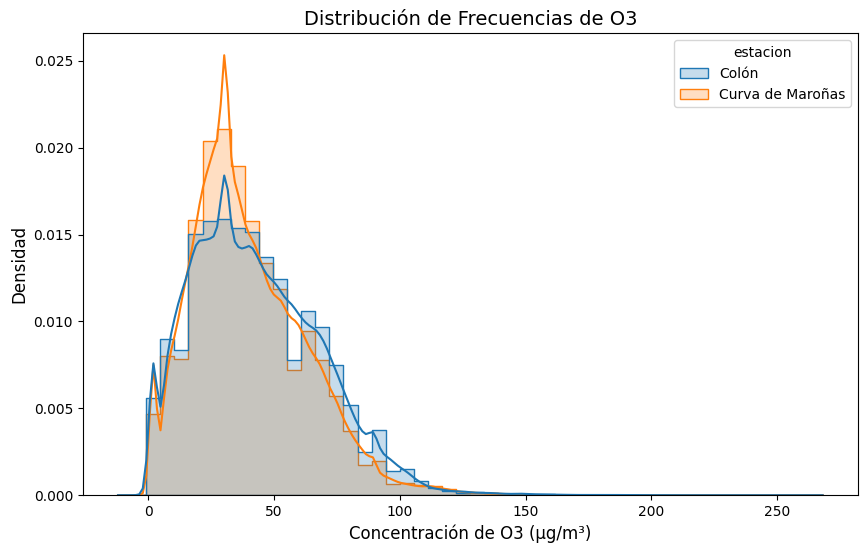

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_purgado,
    x='o3',
    hue='estacion',
    element='step',
    stat='density',
    common_norm=False,
    kde=True,
    bins=50
)
plt.title("Distribución de Frecuencias de O3", fontsize=14)
plt.xlabel("Concentración de O3 (µg/m³)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.show()

In [ ]:
# Este es un elemento a destacar: se consultó a un experto de Uruguay sobre la lectura de los sensores de Ozono tropósferico
# El experto en cuestión es el Dr. José Cataldo, profesor con Dedicación Total (DT) en la Facultad de Ingeniería de la Universidad de la República
# Con sus consejos en cuenta, se procedió a:
#           1) Todo valor negativo, fue nivelado a cero absoluto
#           2) Se tomarán los picos de o3 como acontecimientos recurrentes y esperables
# Los valores de o3 negativos podrían deberse a errores de sensor o valores minúsculos de éste gas.
# Los picos de más de 150µg/m³ son esperables en mediciones

df_purgado.loc[df_purgado['o3'] < 0, 'o3'] = 0
print("Valores negativos restantes:", (df_purgado['o3'] < 0).sum())
print("Mínimo de o3 ahora:", df_purgado['o3'].min())

Valores negativos restantes: 0
Mínimo de o3 ahora: 0.0


In [ ]:
# Se encontró necesario identificar los registros con picos.
# Para identificar en qué momento ocurren esos 1002 picos altos se decidió filtrar, contar y graficar los resultados
# ---------------- --------------------- ---------------------------- ---------------------------
picos = df_purgado[df_purgado['o3'] > 150]

tabla_picos = (
    picos['hora_de_la_muestra']
    .value_counts()

# ---------------------------------------------------
# La siguiente parte del código es importante
# Si no utilizamos la función .reindex y forzamos que muestre las 24 horas, mostrará unicamente datos en donde los haya
# En otras palabras, en los rangos horarios de 0 a 9, y de 22 a 23 no hay picos mayores a 150µg/m³
# La única diferencia real es la claridad, solamente eso
    .reindex(range(0, 24), fill_value=0)
# ---------------------------------------------------

    .reset_index()
)

tabla_picos.columns = ['Hora del Día', 'Cantidad de Picos']

# Debido a la importancia de la transparencia en este proyecto, admito este la siguiente configuración visual fue brindada por IA.
# Los análisis, fetchs, graficaciones, importaciones y eliminaciones son autoría humana.
tabla_picos.style.background_gradient(cmap='Reds', subset=['Cantidad de Picos'])\
                 .hide(axis='index')

Hora del Día,Cantidad de Picos
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


## Identificación y manejo de irregularidades

### Verifiquemos los datos del df_purgado

In [ ]:
# Antes de comenzar a graficar, habría que ver cuántos datos hay por año para cada estación
# Esto demuestra que los datos son dispares
df_purgado['año'] = df_purgado['fecha'].dt.year
años = df_purgado.groupby(["año", "estacion"])["o3"].agg(Count='count')
años

Count
año  estacion                
2024 Colón             229761
     Curva de Maroñas  413907
2025 Colón             155079
     Curva de Maroñas  404394
2026 Colón             359711
     Curva de Maroñas  255481

In [ ]:
df_purgado['mes_numero'] = df_purgado['fecha'].dt.month

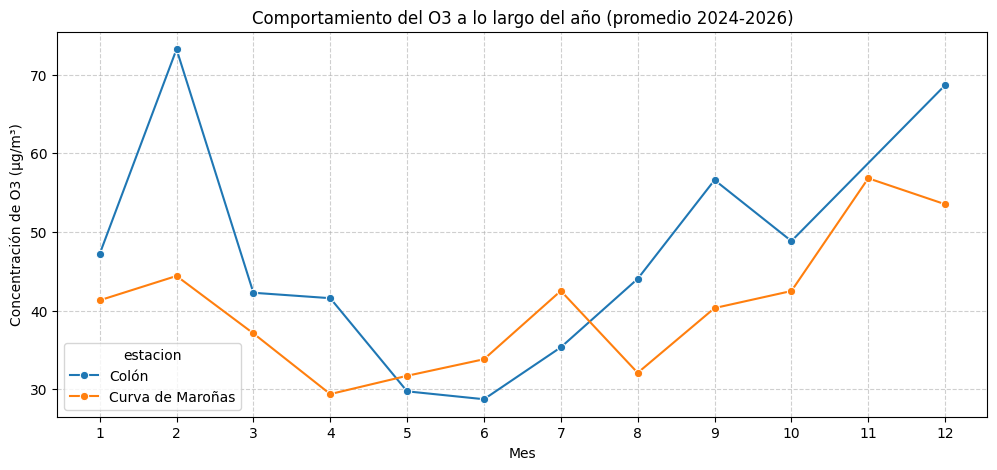

In [ ]:
# El siguiente gráfico muestra que algo pasó con los datos de febrero en la estación Colón
perfil_mensual = df_purgado.groupby(["mes_numero", "estacion"])["o3"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=perfil_mensual,
    x='mes_numero',
    y='o3',
    hue='estacion',
    marker='o'
)

plt.title("Comportamiento del O3 a lo largo del año (promedio 2024-2026)")
plt.xlabel("Mes")
plt.ylabel("Concentración de O3 (µg/m³)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Ahora hay que revisar los datos de la estación Colón en meses y por año

In [ ]:
datos_por_mes_2024 = df_purgado[df_purgado['año'] == 2024].groupby(['estacion', 'mes_numero'])['o3'].agg(Count='count')
tabla_2024 = datos_por_mes_2024.unstack(level='mes_numero', fill_value=0)
tabla_2024

Count                                                   \
mes_numero           1      2      3      4      5      6      7      8    
estacion                                                                   
Colón             39029   1738  34523  37539  35259  33949  27162  20562   
Curva de Maroñas  42671  41216  25943  33108  34287  35943  24271  40468   

                                              
mes_numero           9      10     11     12  
estacion                                      
Colón                 0      0      0      0  
Curva de Maroñas  40345  42290  10621  42744

In [ ]:
datos_por_mes_2025 = df_purgado[df_purgado['año'] == 2025].groupby(['estacion', 'mes_numero'])['o3'].agg(Count='count')
tabla_2025 = datos_por_mes_2025.unstack(level='mes_numero', fill_value=0)
tabla_2025

Count                                                   \
mes_numero           1      2      3      4      5      6      7      8    
estacion                                                                   
Colón                 0      0      0      0      0  24453  22914  36875   
Curva de Maroñas  44373  39989  43551  38058  39289   6440  23609  33387   

                                              
mes_numero           9      10     11     12  
estacion                                      
Colón             10482  29835      0  30520  
Curva de Maroñas   8773  43120  41049  42756

In [ ]:
datos_por_mes_2026 = df_purgado[df_purgado['año'] == 2026].groupby(['estacion', 'mes_numero'])['o3'].agg(Count='count')
tabla_2026 = datos_por_mes_2026.unstack(level='mes_numero', fill_value=0)
tabla_2026

Count                                                   \
mes_numero            1      2      3      4      5      6      7      8   
estacion                                                                   
Colón             44572  39987  43962  41297  38558  35973  43209  44119   
Curva de Maroñas  44221  40157  44435  39706  32130  11075  32731   9111   

                         
mes_numero            9  
estacion                 
Colón             28034  
Curva de Maroñas   1915

### 2) Verifiquemos los datos del o3_completo (archivo original)

Se identificó un hueco en los datos entre el 01/09/2024 y el 31/05/2025. Debemos intentar diagnosticar si esos datos no existían desde el principio, para lo cual usaremos el df original (o3_completo) o si todos los datos que se encontraban dentro eran NaN y fueron borrados.

**Conclusión** Se llegó a la conclusión de que en el período de tiempo 01/09/2024 - 31/05/2025 **no hay datos para la estación Colón**. Se consultó a la IMM en caso de que tengan los datos o puedan brindar alguna explicación.

In [ ]:
# Primero vamos a verificar que el df o3_completo sea el original
# Debemos confirmar que no es la versión la cual se le eliminó los datos nulos

print("Filas totales en o3_completo:", len(o3_completo))
print("--------------------")
print("Rango de fechas:", o3_completo['fecha'].min(),"a", o3_completo['fecha'].max())
print("--------------------")
print("Estaciones presentes:", o3_completo['estacion'].unique())

Filas totales en o3_completo: 2191596
--------------------
Rango de fechas: 2024-01-01 00:00:00 a 2026-09-21 23:59:00
--------------------
Estaciones presentes: ['Colón' 'Curva de Maroñas']


In [ ]:
# Confirmamos anteriormente que es el df original, no el modificado
# Confirmamos que no existen datos entre esas fechas
# Por puro excepticismo correremos la siguiente prueba para verificar

colon_2024_2025_septiembre_mayo = o3_completo[
    (o3_completo['fecha'] >= '2024-09-01') &
    (o3_completo['fecha'] <= '2025-05-31') &
    (o3_completo['estacion'] == 'Colón')
]

print("Total de filas (con nulos incluidos):", len(colon_2024_2025_septiembre_mayo))
print("De esas, con o3 nulo:", colon_2024_2025_septiembre_mayo['o3'].isna().sum())
print("De esas, con o3 válido (no nulo):", colon_2024_2025_septiembre_mayo['o3'].notna().sum())

Total de filas (con nulos incluidos): 0
De esas, con o3 nulo: 0
De esas, con o3 válido (no nulo): 0


### Graficación para la estación Colón


/tmp/ipykernel_1211/2496924359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


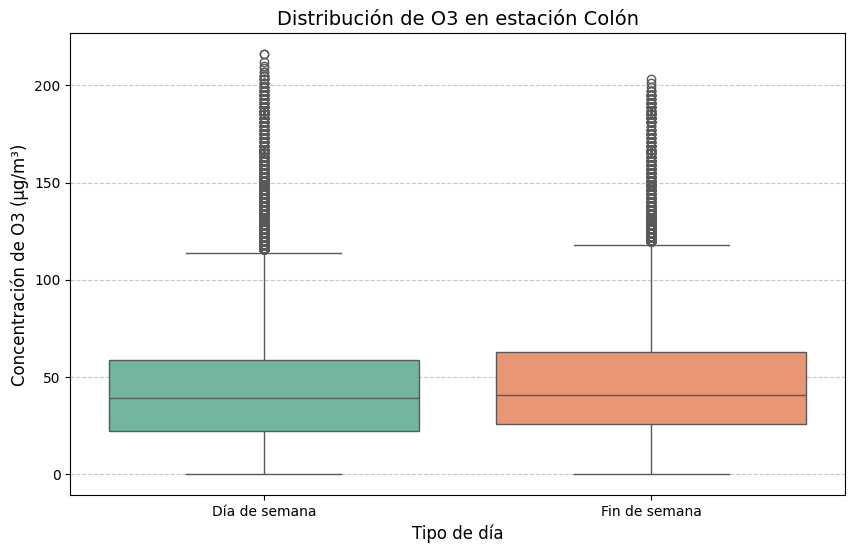

In [ ]:
# La idea es usar este boxplot para revisar los datos extraños, sobre todo aquellos negativos y las mediciones extremadamente altas
colon_bp = df_purgado[df_purgado['estacion'] == 'Colón']
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=colon_bp,
    x='tipo_dia',
    y='o3',
    palette='Set2',
    showfliers=True
)
plt.title("Distribución de O3 en estación Colón", fontsize=14)
plt.xlabel("Tipo de día", fontsize=12)
plt.ylabel("Concentración de O3 (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

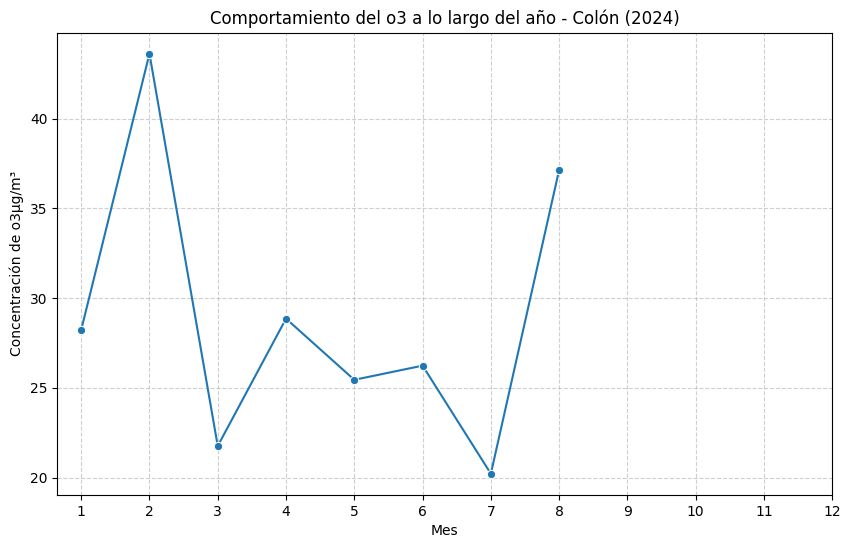

In [ ]:
perfil_mensual_colon2024 = colon_bp[colon_bp['año'] == 2024].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(
    data = perfil_mensual_colon2024,
    x = 'mes_numero',
    y = 'o3',
    marker = 'o'
)
plt.title("Comportamiento del o3 a lo largo del año - Colón (2024)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

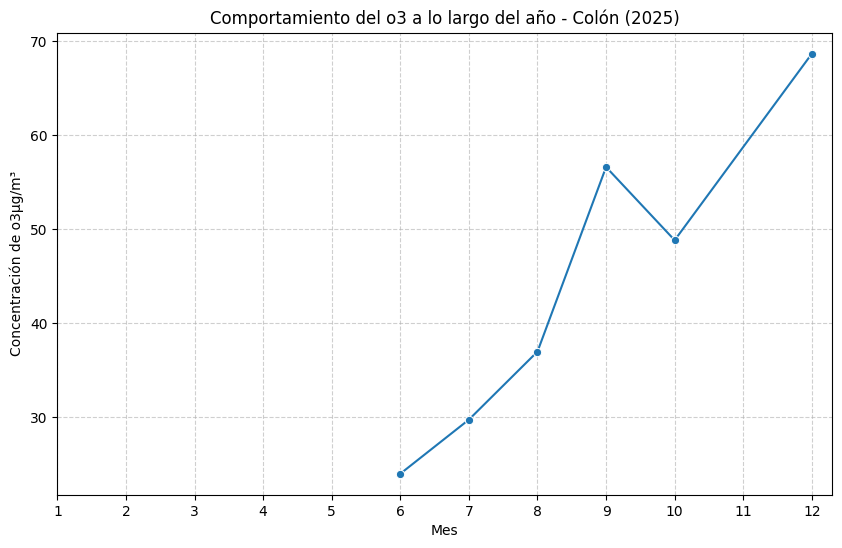

In [ ]:
perfil_mensual_colon2025 = colon_bp[colon_bp['año'] == 2025].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(
    data = perfil_mensual_colon2025,
    x = 'mes_numero',
    y = 'o3',
    marker = 'o'
)
plt.title("Comportamiento del o3 a lo largo del año - Colón (2025)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

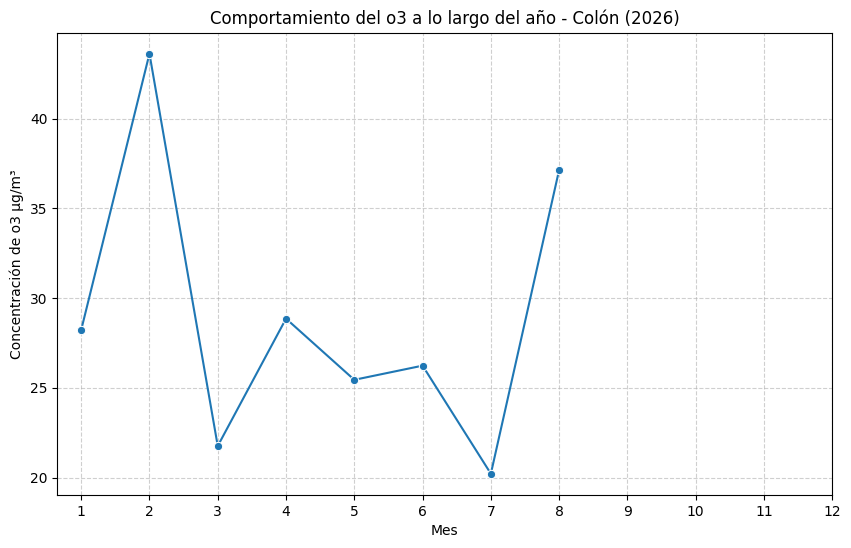

In [ ]:
perfil_mensual_colon2026 = colon_bp[colon_bp['año'] == 2026].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(
    data = perfil_mensual_colon2024,
    x = 'mes_numero',
    y = 'o3',
    marker = 'o'
)
plt.title("Comportamiento del o3 a lo largo del año - Colón (2026)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show



/tmp/ipykernel_1211/2124423680.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


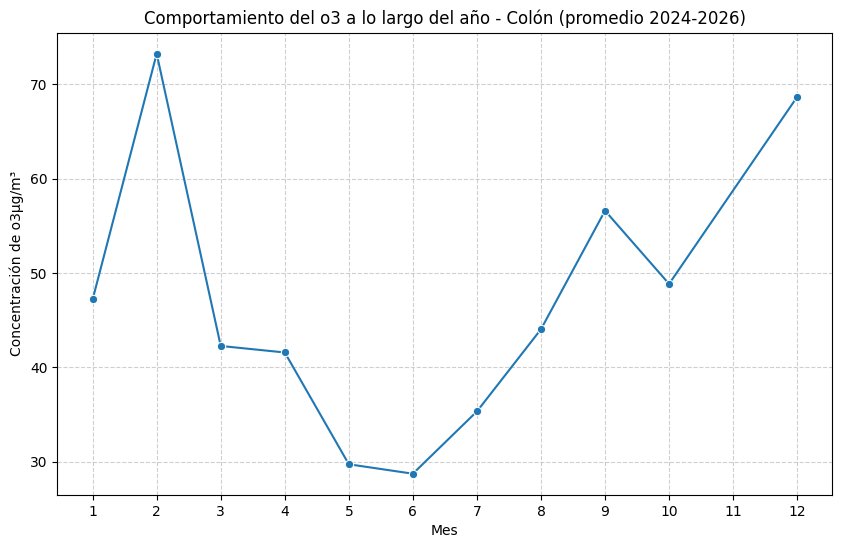

In [ ]:
# Gráfico promedio (2024-2026)

perfil_mensual_colon = colon_bp.groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(
    data = perfil_mensual_colon,
    x ='mes_numero',
    y ='o3',
    palette ='Set2',
    marker ='o'
)
plt.title("Comportamiento del o3 a lo largo del año - Colón (promedio 2024-2026)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha= 0.6)
plt.show()

### Graficación de estación Curva de Maroñas

/tmp/ipykernel_1211/1511244536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


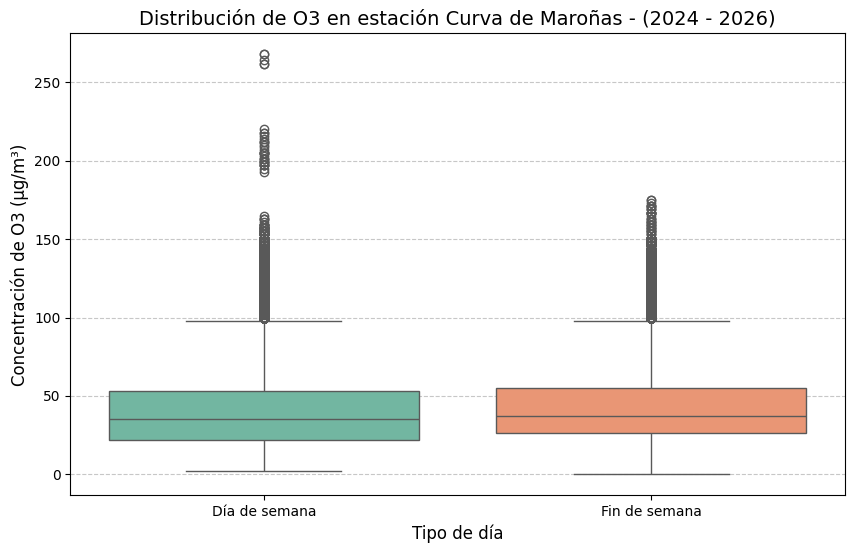

In [ ]:
# La idea es usar este boxplot para revisar los datos extraños, sobre todo aquellos negativos y las mediciones extremadamente altas
maroñas_bp = df_purgado[df_purgado['estacion'] == 'Curva de Maroñas']
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=maroñas_bp,
    x='tipo_dia',
    y='o3',
    palette='Set2',
    showfliers=True
)
plt.title("Distribución de O3 en estación Curva de Maroñas - (2024 - 2026)", fontsize=14)
plt.xlabel("Tipo de día", fontsize=12)
plt.ylabel("Concentración de O3 (µg/m³)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Promedio de o3 en colon_bp:", colon_bp['o3'].mean())
print("Promedio de o3 en maroñas_bp:", maroñas_bp['o3'].mean())

Promedio de o3 en colon_bp: 42.98036400461486
Promedio de o3 en maroñas_bp: 39.80217213549864


In [ ]:
# Debido a que en el boxplot anterior hay 'espacios en blanco'
# Se decidió verificar porqué existen esos 'vacíos'
# Por esto, se verifica a continuación si hay datos entre los rangos 155-195 y 235-255
# Como resultado, existen datos dentro de esas brechas pero no aparecen en el boxplot
# No aparecen los datos porque son pocos

valores_maronas1 = df_purgado[
    (df_purgado['o3'] > 155) &
    (df_purgado['o3'] < 195) &
    (df_purgado['estacion'] == 'Curva de Maroñas') &
    (df_purgado['tipo_dia'] == 'Día de semana')
]

valores_maronas2 = df_purgado[
    (df_purgado['o3'] > 235) &
    (df_purgado['o3'] < 255) &
    (df_purgado['estacion'] == 'Curva de Maroñas') &
    (df_purgado['tipo_dia'] == 'Dia de semana')
]

print("Cantidad de registros en el rango 155-195:", len(valores_maronas1))
print("Cantidad de registros en el rango 235-255:", len(valores_maronas2))

Cantidad de registros en el rango 155-195: 21
Cantidad de registros en el rango 235-255: 0


<function matplotlib.pyplot.show(close=None, block=None)>

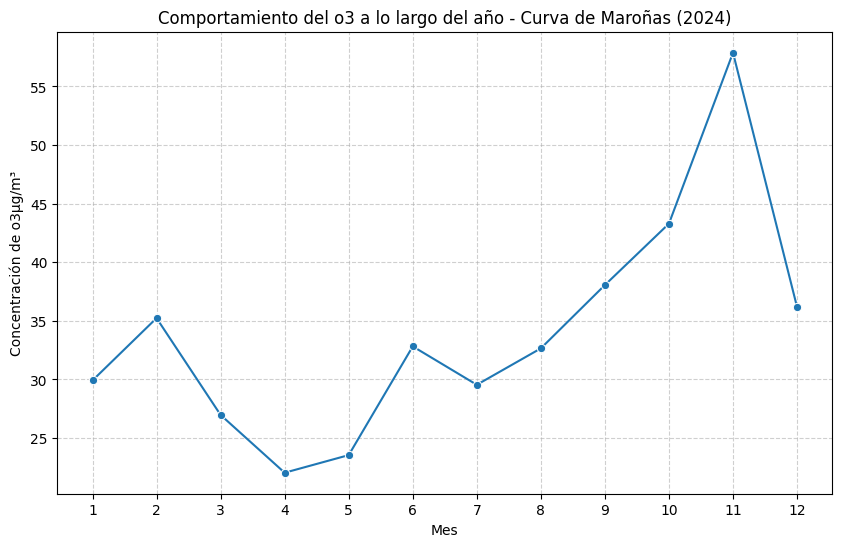

In [ ]:
perfil_mensual_maronas2024 = maroñas_bp[maroñas_bp['año'] == 2024].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize= (10, 6))
sns.lineplot(
    data= perfil_mensual_maronas2024,
    x= 'mes_numero',
    y= 'o3',
    marker='o'
)
plt.title("Comportamiento del o3 a lo largo del año - Curva de Maroñas (2024)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

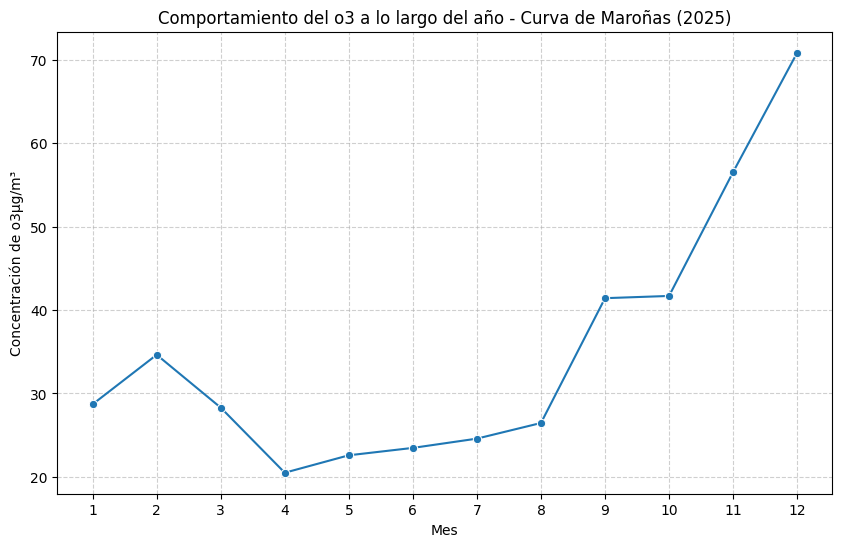

In [ ]:
perfil_mensual_maronas2025 = maroñas_bp[maroñas_bp['año'] == 2025].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize= (10, 6))
sns.lineplot(
    data= perfil_mensual_maronas2025,
    x= 'mes_numero',
    y= 'o3',
    marker='o'
)
plt.title("Comportamiento del o3 a lo largo del año - Curva de Maroñas (2025)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

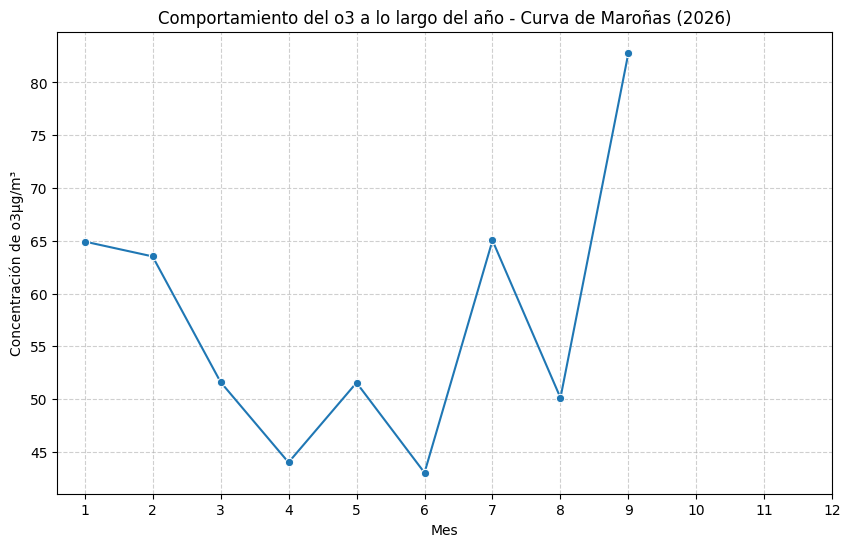

In [ ]:
perfil_mensual_maronas2026 = maroñas_bp[maroñas_bp['año'] == 2026].groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize= (10, 6))
sns.lineplot(
    data= perfil_mensual_maronas2026,
    x= 'mes_numero',
    y= 'o3',
    marker='o'
)
plt.title("Comportamiento del o3 a lo largo del año - Curva de Maroñas (2026)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

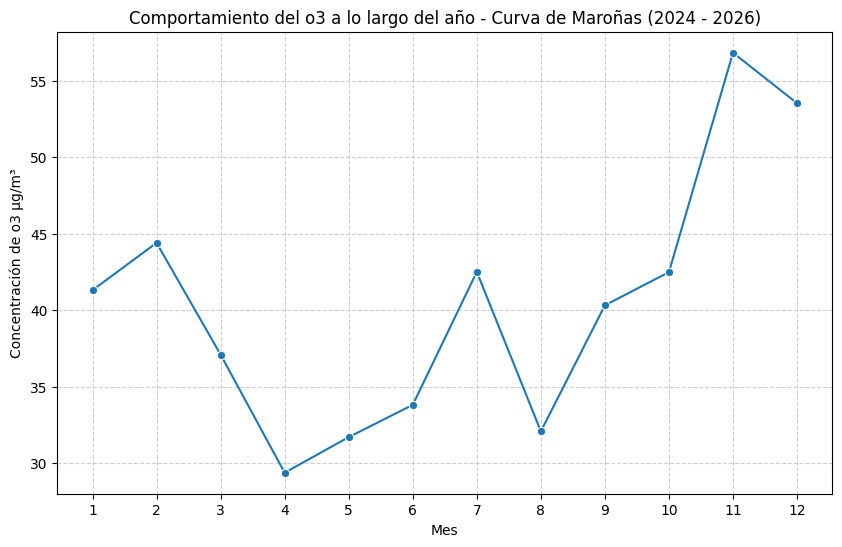

In [ ]:
perfil_mensual_maroñas = maroñas_bp.groupby(['mes_numero'])['o3'].mean().reset_index()
plt.figure(figsize= (10, 6))
sns.lineplot(
    data= perfil_mensual_maroñas,
    x= 'mes_numero',
    y= 'o3',
    marker='o'
)
plt.title("Comportamiento del o3 a lo largo del año - Curva de Maroñas (2024 - 2026)")
plt.xlabel("Mes")
plt.ylabel("Concentración de o3 µg/m³")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show

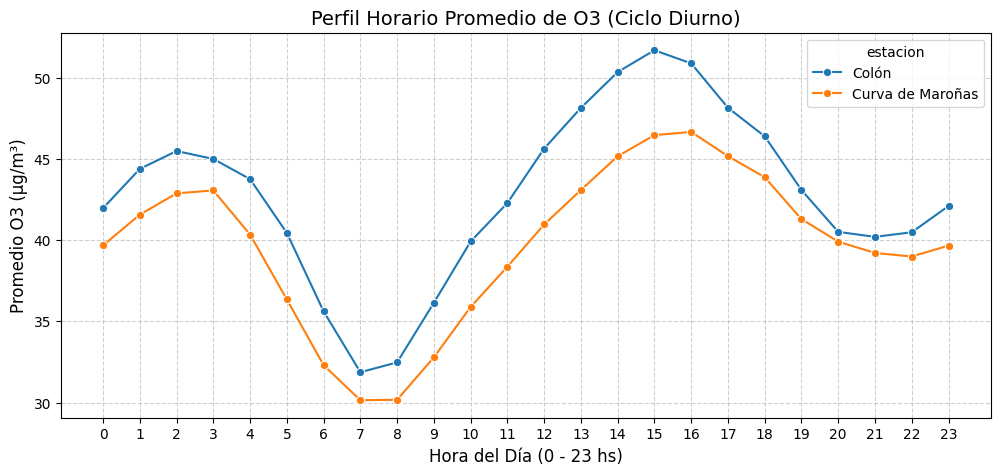

In [ ]:
# Perfil Horario Promedio (Ciclo Diurno del Ozono)
perfil_horario = df_purgado.groupby(["hora_de_la_muestra", "estacion"])["o3"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=perfil_horario,
    x='hora_de_la_muestra',
    y='o3',
    hue='estacion',
    marker='o'
)
plt.title("Perfil Horario Promedio de O3 (Ciclo Diurno)", fontsize=14)
plt.xlabel("Hora del Día (0 - 23 hs)", fontsize=12)
plt.ylabel("Promedio O3 (µg/m³)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()